# **Import required libraries**

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

# **Load and preprocess data**
This portion is to further prepare the data for initial exploratory data analysis. 
- Create a proper `'Date'` column for time-series analysis
- Calculate Monthly and Yearly average prices

From the visualization graphs, we can see an overall increasing trend in resale flat prices from $442246 in 2017 to $617867 in 2025. Particularly, we notice that the prices have:
- A plateau in 2019 to 2020
- A short period of decrease before increasing rapidly after mid-2020
    - The Straits Times reported that the **prices rose 5% in 2020** and the **transaction volume increased by 4.4%** from 2019. The writers explained that this increase, despite the economy being hit by the Covid-19 pandemic, is not surprising given the **extensive government stimulus** such as the Jobs Support Scheme to support the economy, giving buyers the condifence that they will be able to service their loan. (Source: [The Straits Times](https://www.straitstimes.com/business/property/sales-of-hdb-resale-flats-hit-8-year-high-in-2020-as-prices-climb-5))

## Resale Flat Data

In [95]:
df = pd.read_csv('../datasets/Final_ResaleData.csv')
print('Dataset shape:', df.shape)
df.sample(5)

Dataset shape: (212868, 10)


,Year,Month,Storey,Floor_Area,Remaining_Lease,Price,Distance_MRT,Distance_Mall,Within_1km_of_Pri,Mature
96160,2021,4,10,104.0,67.000,458000.0,1458,1428,True,True
199551,2025,5,10,91.0,54.250,558000.0,1641,760,False,True
29628,2018,6,1,67.0,65.583,282000.0,1076,1008,False,True
7476,2017,5,1,83.0,67.500,445000.0,601,532,True,True
14477,2017,9,10,66.0,51.417,339000.0,688,833,False,True


In [96]:
print(df.describe())
df.dtypes

                Year          Month         Storey     Floor_Area  \
count  212868.000000  212868.000000  212868.000000  212868.000000   
mean     2021.082300       6.514455       7.584503      96.414865   
std         2.467264       3.361427       5.621582      23.830564   
min      2017.000000       1.000000       1.000000      31.000000   
25%      2019.000000       4.000000       4.000000      77.000000   
50%      2021.000000       7.000000       7.000000      93.000000   
75%      2023.000000       9.000000      10.000000     112.000000   
max      2025.000000      12.000000      49.000000     215.000000   

       Remaining_Lease          Price   Distance_MRT  Distance_Mall  
count    212868.000000  212868.000000  212868.000000  212868.000000  
mean         74.194438  510213.368192    1077.931065    1309.502194  
std          14.202390  167007.223313     575.167499     672.138370  
min          40.083000  140000.000000      48.000000      49.000000  
25%          62.500000  3800

Year                   int64
Month                  int64
Storey                 int64
Floor_Area           float64
Remaining_Lease      float64
Price                float64
Distance_MRT           int64
Distance_Mall          int64
Within_1km_of_Pri       bool
Mature                  bool
dtype: object

In [97]:
# Add 'Date' column
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(DAY=1))
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Year,Month,Storey,Floor_Area,Remaining_Lease,Price,Distance_MRT,Distance_Mall,Within_1km_of_Pri,Mature,Date
0,2017,1,10,44.0,61.333,232000.0,1148,1276,True,True,2017-01-01
1,2017,1,4,100.0,81.333,335000.0,558,385,True,False,2017-01-01
2,2017,1,1,86.0,82.500,305000.0,851,830,True,False,2017-01-01
3,2017,1,19,110.0,88.917,860000.0,293,737,False,True,2017-01-01
4,2017,1,19,111.0,85.667,800000.0,757,951,True,True,2017-01-01


In [98]:
# Calculate Monthly Average Prices
monthly_avg_prices = df.groupby('Date').agg({
    'Price': ['mean', 'median', 'std', 'count']
    }).reset_index()

monthly_avg_prices.columns = ['Date', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Transaction_Count']
monthly_avg_prices.sample(5)

# Calculate Yearly Average Prices
yearly_avg_prices = df.groupby('Year').agg({
    'Price': ['mean', 'median', 'std', 'count']
    }).reset_index()

yearly_avg_prices.columns = ['Year', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Transaction_Count']
yearly_avg_prices.sample(5)

print('Monthly Average Prices (first 5 rows):' )
print(monthly_avg_prices.head(5))
print('\nYearly Average Prices:')
print(yearly_avg_prices)


Monthly Average Prices (first 5 rows):
        Date     Mean_Price  Median_Price  Std_Dev_Price  Transaction_Count
0 2017-01-01  426443.598478      403000.0  130267.530484               1183
1 2017-02-01  446722.903137      415000.0  146588.271232               1084
2 2017-03-01  443729.275345      415000.0  144431.360286               1899
3 2017-04-01  437682.043377      408000.0  139008.292703               1836
4 2017-05-01  442003.979737      410000.0  145710.924400               1974

Yearly Average Prices:
   Year     Mean_Price  Median_Price  Std_Dev_Price  Transaction_Count
0  2017  442246.549403      410000.0  146053.062002              20452
1  2018  438775.588278      408000.0  152961.360201              21472
2  2019  430058.837131      400000.0  149934.544788              22112
3  2020  449820.332213      425000.0  149765.177374              23240
4  2021  505604.462313      480000.0  152752.358872              28794
5  2022  540876.684146      520000.0  156143.259282    

### Visualization of overall price trend

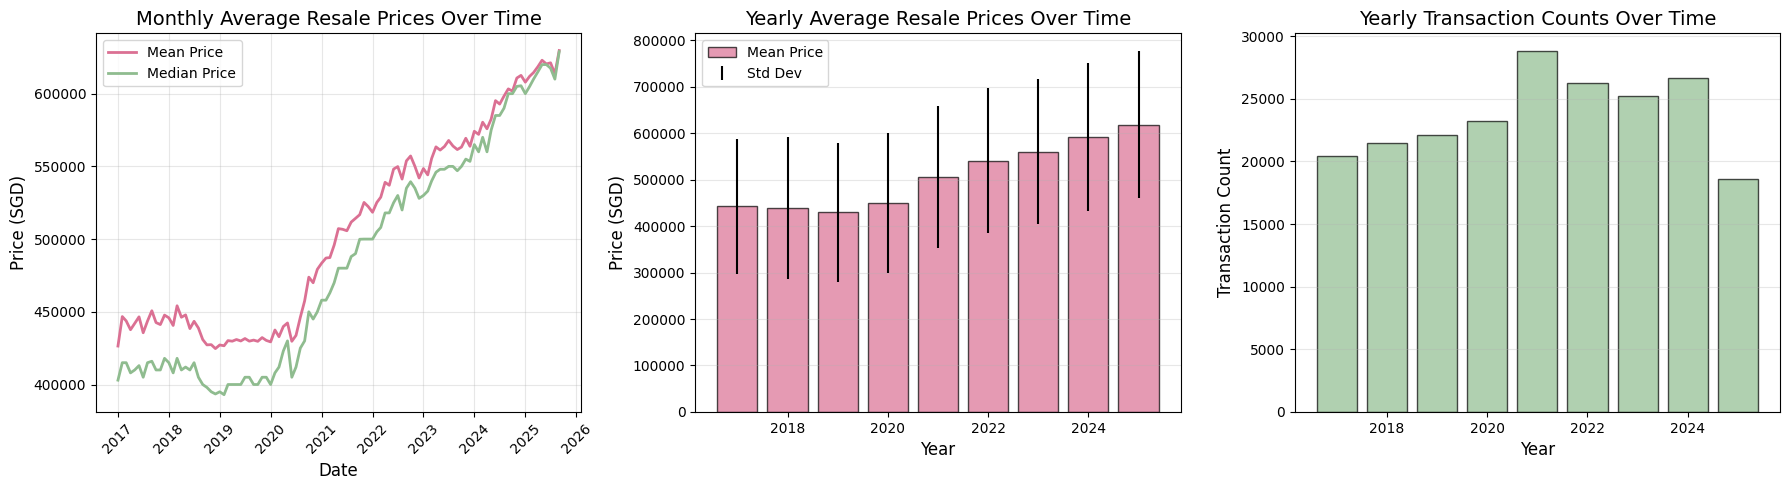

In [99]:
fig, ax =  plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Monthly Average Resale Prices Over Time
ax[0].plot(monthly_avg_prices['Date'], monthly_avg_prices['Mean_Price'],
           linewidth=2, label='Mean Price', color='palevioletred')
ax[0].plot(monthly_avg_prices['Date'], monthly_avg_prices['Median_Price'],
           linewidth=2, label='Median Price', color='darkseagreen')
ax[0].set_title('Monthly Average Resale Prices Over Time', fontsize=14)
ax[0].set_xlabel('Date', fontsize=12)
ax[0].set_ylabel('Price (SGD)', fontsize=12)
ax[0].legend(loc = 'upper left')
ax[0].grid(True, alpha=0.3)
ax[0].tick_params(axis='x', rotation=45)

# Plot 2: Yearly Average Resale Prices Over Time
ax[1].bar(yearly_avg_prices['Year'], yearly_avg_prices['Mean_Price'],
          color='palevioletred', alpha=0.7, label='Mean Price', edgecolor='black')
ax[1].errorbar(yearly_avg_prices['Year'], yearly_avg_prices['Mean_Price'],
               yerr=yearly_avg_prices['Std_Dev_Price'], fmt='none', color='black', label='Std Dev')
ax[1].set_title('Yearly Average Resale Prices Over Time', fontsize=14)
ax[1].set_xlabel('Year', fontsize=12)
ax[1].set_ylabel('Price (SGD)', fontsize=12)
ax[1].legend(loc = 'upper left')
ax[1].grid(True, alpha=0.3, axis = 'y')

# Plot 3: Yearly Transaction Counts Over Time
ax[2].bar(yearly_avg_prices['Year'], yearly_avg_prices['Transaction_Count'],
          color='darkseagreen', alpha=0.7, label='Transaction Count', edgecolor='black')
ax[2].set_title('Yearly Transaction Counts Over Time', fontsize=14)
ax[2].set_xlabel('Year', fontsize=12)
ax[2].set_ylabel('Transaction Count', fontsize=12)
ax[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


### **Analyze Feature Correlations**

From the correlation table, we can see that:
- `'Floor_Area'` is highly correlated to `'Flat_Type'`
    - For this analysis, we choose to remove `'Flat_Type'` since `'Floor_Area'` is a better representation of the amount of space in the flat. Additionally, HDB will be rolling out (['white flats'](https://www.channelnewsasia.com/singapore/hdb-new-open-concept-layout-no-walls-beams-bto-kallang-whampoa-4365806)) from October 2025. By using floor area, it would better represent the future resale of these 'white flats' that might not have the same concept of 'number of rooms' as older flats. 
- `'Price'` is highly correlated to `'Floor_Area'`, `'Year'`, `'Remaining_Lease'` and `'Storey'`
- `'Price'` is less correlated to its distance to amenities such as malls and MRT stations

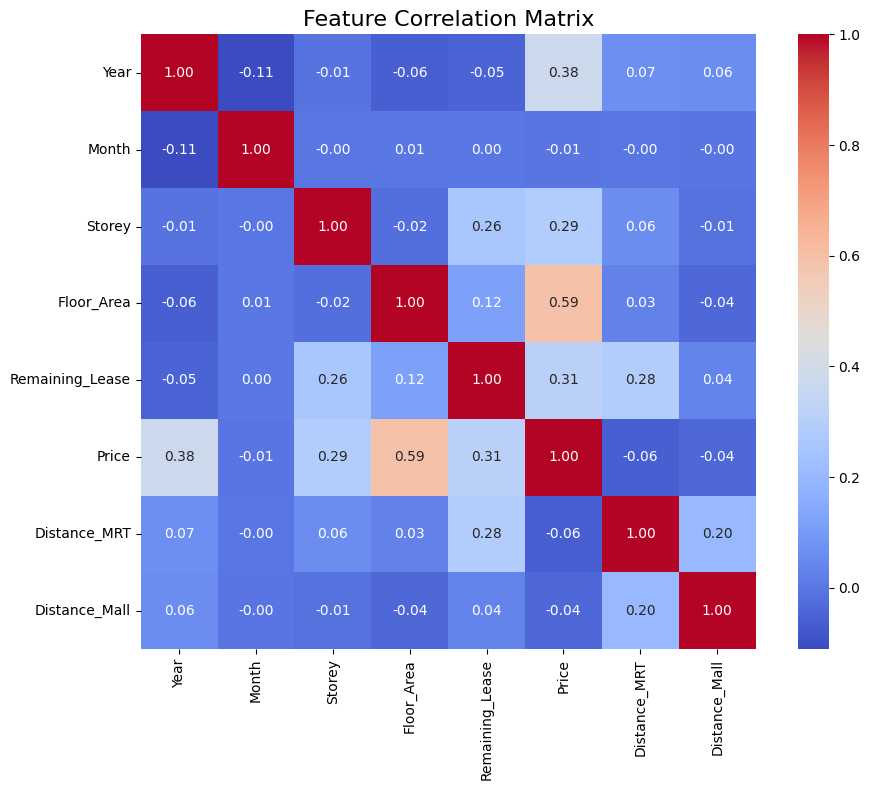

In [100]:
# Create correlation matrix for numerical features
numerical_features = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_features.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

### **Prepare data for modelling**

In [101]:
# Convert boolean features to integers
df['Within_1km_of_Pri_Int'] = df['Within_1km_of_Pri'].astype(int)
df['Mature_Int'] = df['Mature'].astype(int)

# The following features will be selected for modelling:
features = [ 
    'Year', 
    'Month',
    'Storey',
    'Floor_Area',
    'Remaining_Lease',
    'Distance_MRT',
    'Distance_Mall',
    'Within_1km_of_Pri_Int',
    'Mature_Int',
    ]

target = 'Price'

df1 = df[features + [target] + ['Date']].copy()
df1.dropna().reset_index(drop=True)

X = df1[features]
y = df1[target]

print(f"Total samples: {len(X)}")
print(f"Date range: {df1['Date'].min()} to {df1['Date'].max()}")

# Split data into training and testing sets chronologically (80% train, 20% test)
train_size = int(0.8 * len(X))
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Check training and testing dates
train_dates = df1['Date'].iloc[:train_size]
test_dates = df1['Date'].iloc[train_size:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}") 
print(f"Training period: {train_dates.min()} to {train_dates.max()}")
print(f"Testing period: {test_dates.min()} to {test_dates.max()}")


Total samples: 212868
Date range: 2017-01-01 00:00:00 to 2025-09-01 00:00:00
Training samples: 170294
Testing samples: 42574
Training period: 2017-01-01 00:00:00 to 2024-02-01 00:00:00
Testing period: 2024-02-01 00:00:00 to 2025-09-01 00:00:00


# **Random Forest**

Evaluation is carried out using MAE, RMSE and R^2 to assess prediction accuracy. The scores are as such:

MAE: 53219.98\
RMSE: 68633.35\
R2: 0.814

On average predictions are off by $53k on new data, and predictions are off by $68k when using RMSE. The model explains about 81.4% of the variation in prices. 

Most important feature is Floor Area


In [102]:
# Training Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100,
                                 random_state=42,
                                 max_depth=30,
                                 min_samples_split=5,
                                 min_samples_leaf=2,
                                 n_jobs=-1
                                 )

rf_model.fit(X_train, y_train)
print("Random Forest model training complete.")

Random Forest model training complete.


In [103]:
# Predicting on training set
y_train_pred_rf = rf_model.predict(X_train)
# Predicting on test set
y_test_pred_rf = rf_model.predict(X_test)

# Evaluation
# Mean Absolute Error (MAE)
rf_train_mae = mean_absolute_error(y_train, y_train_pred_rf)
rf_test_mae = mean_absolute_error(y_test, y_test_pred_rf)

print(f"Random Forest Training MAE: {rf_train_mae}")
print(f"Random Forest Testing MAE: {rf_test_mae}")

# Root Mean Squared Error (RMSE)
rf_train_rmse = root_mean_squared_error(y_train, y_train_pred_rf)
rf_test_rmse = root_mean_squared_error(y_test, y_test_pred_rf)

print(f"Random Forest Training RMSE: {rf_train_rmse}")
print(f"Random Forest Testing RMSE: {rf_test_rmse}")

# R-squared (R2) Score
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

print(f"Random Forest Training R2: {rf_train_r2}")
print(f"Random Forest Testing R2: {rf_test_r2}")

Random Forest Training MAE: 12323.664436276595
Random Forest Testing MAE: 53291.767472199725
Random Forest Training RMSE: 18344.71532180525
Random Forest Testing RMSE: 68614.76295986792
Random Forest Training R2: 0.9869410641019767
Random Forest Testing R2: 0.8148939141015716


In [104]:
#Analyse Prediction Errors
rf_test_errors = y_test - y_test_pred_rf

within_50k = np.sum(np.abs(rf_test_errors) <= 50000)/len(y_test)*100
print(f"Percentage of test predictions within ±$50,000: {within_50k:.2f}%")
within_100k = np.sum(np.abs(rf_test_errors) <= 100000)/len(y_test)*100
print(f"Percentage of test predictions within ±$100,000: {within_100k:.2f}%")
more_than_100k = np.sum(np.abs(rf_test_errors) > 100000)/len(y_test)*100
print(f"Percentage of test predictions with error more than ±$100,000: {more_than_100k:.2f}%")

Percentage of test predictions within ±$50,000: 56.04%
Percentage of test predictions within ±$100,000: 87.54%
Percentage of test predictions with error more than ±$100,000: 12.46%


In [105]:
# Feature Importance for Random Forest
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(feature_importance)

Feature Importance (Random Forest):
                 Feature  Importance
3             Floor_Area    0.485165
4        Remaining_Lease    0.133977
8             Mature_Int    0.128339
0                   Year    0.117900
5           Distance_MRT    0.046033
6          Distance_Mall    0.040411
2                 Storey    0.032357
7  Within_1km_of_Pri_Int    0.008137
1                  Month    0.007680


# **Linear Regression**

Evaluation is carried out using MAE, RMSE and R^2 to assess prediction accuracy. The scores are as such:

MAE: 60805.22\
RMSE: 80252.47\
R2: 0.747

On average predictions are off by $60k on new data, and predictions are off by $80k when using RMSE. The model explains about 74.7% of the variation in prices. 

Most important feature is whether or not the estate is a mature one


In [106]:
# Training Linear Regression Model
lm = LinearRegression()
lm.fit(X_train, y_train)
print("Linear Regression model training complete.")

Linear Regression model training complete.


In [107]:
# Make predictions
y_train_pred_lm = lm.predict(X_train)
y_test_pred_lm = lm.predict(X_test)

# Evaluation
# Mean Absolute Error (MAE)
lm_train_mae = mean_absolute_error(y_train, y_train_pred_lm)
lm_test_mae = mean_absolute_error(y_test, y_test_pred_lm)
print(f"Linear Regression Training MAE: {lm_train_mae}")
print(f"Linear Regression Testing MAE: {lm_test_mae}")

# Root Mean Squared Error (RMSE)
lm_train_rmse = root_mean_squared_error(y_train, y_train_pred_lm)
lm_test_rmse = root_mean_squared_error(y_test, y_test_pred_lm)
print(f"Linear Regression Training RMSE: {lm_train_rmse}")
print(f"Linear Regression Testing RMSE: {lm_test_rmse}")

# R-squared (R2) Score
lm_train_r2 = r2_score(y_train, y_train_pred_lm)
lm_test_r2 = r2_score(y_test, y_test_pred_lm)
print(f"Linear Regression Training R2: {lm_train_r2}")
print(f"Linear Regression Testing R2: {lm_test_r2}")



Linear Regression Training MAE: 58588.86721636501
Linear Regression Testing MAE: 60802.83648433518
Linear Regression Training RMSE: 75936.49175063621
Linear Regression Testing RMSE: 80249.69892786983
Linear Regression Training R2: 0.7762377116964135
Linear Regression Testing R2: 0.7467949363938191


In [108]:
# Feature Importance for Linear Regression
lm_coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lm.coef_
})
lm_coefficients = lm_coefficients.sort_values(by='Coefficient', ascending=False)
print("Feature Coefficients (Linear Regression):")
print(lm_coefficients)

Feature Coefficients (Linear Regression):
                 Feature    Coefficient
8             Mature_Int  125878.142912
0                   Year   27334.183906
2                 Storey    6170.368042
4        Remaining_Lease    4625.220375
3             Floor_Area    4296.653182
1                  Month    1827.328095
6          Distance_Mall     -10.511084
5           Distance_MRT     -43.703246
7  Within_1km_of_Pri_Int  -26366.863583


# **Predicting price of HDB flats in X years**

Previously, Random Forest and Linear Regression were trained on chronologically split data, where the data was ordered by date before a 80-20 split was done to separate the training and test data set. In this way, 'past' prices were used to train the models, and tested on 'future' datasets. 

This chronological split simulates real-world forecasting, where the model learns form historical transactions (2017 to early 2024) and predicts prices for a later period (late 2024 to 2025).  
Since these 'future' transcations have already occurred and we have their actual flat prices (test_y), we could validate the models' performance using metrics like MAE, RMSE and R<sup>2</sup>.

However, predicting prices for the *true future* (eg 2026, 2030 etc) is challenging because there are no actual transaction prices to compare against, hence there can be no test_y to validate our predictions. 

Therefore, these prices would be **estimates** based on learned historical patterns, with the following assumptions:

1. Market trends continue. The relationship between features (floor area, remaining lease etc) and price continues
2. Year-on-year price changes observed in training data continues into the future
3. No major disruptions such as policy changes, economic shocks or events that would affect pricing dynamics and consumer behaviour

## Making future predictions

To predict a flat's price in X years, we adjust for time-dependent features. `'Year'` is increased by X years where as `'Remaining_Lease'` is decreased by X years. Other features remain constant. 

However, since future predictions cannot be validated with actual data, there can be risk of extrapolation. Current market trends may not continue into the future, and any policy changes or economic factors that occur may drastically alter market behaviour which cannot be predicted by the model



In [109]:
# Create floor area ranges to approximate the different flat types
floor_area_bins = {
    '1-Room': 30,
    '2-Room': 60,
    '3-Room': 90,
    '4-Room': 100,
    '5-Room': 115,
}

# Create storey level bins
storey_bins = {
    'Low': 5,
    'Mid': 15,
    'High': 30
}

# Remaining lease categories
lease_bins = {
    'Short': 50,
    'Medium': 70,
    'Long': 99
}

print("Example Flats for Prediction:")
print(f"Floor Area Bins: {len(floor_area_bins)}")
print(f"Storey Level Bins: {len(storey_bins)}")
print(f"Remaining Lease Bins: {len(lease_bins)}")
print(f"Total combinations: {len(floor_area_bins) * len(storey_bins) * len(lease_bins)}")

Example Flats for Prediction:
Floor Area Bins: 5
Storey Level Bins: 3
Remaining Lease Bins: 3
Total combinations: 45


In [110]:
# Creating example flat configurations
configurations = []
config_id = 1
for flat_type, area in floor_area_bins.items():
    for storey_level, storey in storey_bins.items():
        for lease_category, lease in lease_bins.items():
            config = {
                'Config_ID': config_id,
                'Flat_Type': flat_type,
                'Floor_Area': area,
                'Storey_Level': storey_level,
                'Storey': storey,
                'Remaining_Lease': lease,
                'Year': 2025,
                'Month': 6,
                'Distance_MRT': df['Distance_MRT'].mean(),  # Example fixed distance
                'Distance_Mall': df['Distance_Mall'].mean(),  # Example fixed distance
                'Within_1km_of_Pri_Int': 1,  # Assume within 1km
                'Mature_Int': 0  # Assume non-mature estate
            }
            configurations.append(config)
            config_id += 1

example_flats = pd.DataFrame(configurations)
print(f"Created {len(example_flats)} example flat configurations.")
example_flats.head()

Created 45 example flat configurations.


,Config_ID,Flat_Type,Floor_Area,Storey_Level,Storey,Remaining_Lease,Year,Month,Distance_MRT,Distance_Mall,Within_1km_of_Pri_Int,Mature_Int
0,1,1-Room,30,Low,5,50,2025,6,1077.931065,1309.502194,1,0
1,2,1-Room,30,Low,5,70,2025,6,1077.931065,1309.502194,1,0
2,3,1-Room,30,Low,5,99,2025,6,1077.931065,1309.502194,1,0
3,4,1-Room,30,Mid,15,50,2025,6,1077.931065,1309.502194,1,0
4,5,1-Room,30,Mid,15,70,2025,6,1077.931065,1309.502194,1,0


In [111]:
# Predicting prices over 20 years for all configurations using Random Forest model
def predict_future_prices(curr_flat_data, years_ahead, model, features):
    future_features = curr_flat_data.copy()
    future_features['Year'] += years_ahead
    future_features['Remaining_Lease'] -= years_ahead

    if future_features['Remaining_Lease'].iloc[0] < 0:
        future_features['Remaining_Lease'] = 0
    
    feature_vectors = future_features[features]
    predicted_prices = model.predict(feature_vectors)[0]
    return predicted_prices

# Predict prices for each configuration over the next 20 years
all_predictions = []
years_range = range(0, 21)  # 0 to 20 years ahead

for idx, config in example_flats.iterrows():
    for year in years_range:
        predicted_price = predict_future_prices(
            curr_flat_data=config.to_frame().T,
            years_ahead=year,
            model=rf_model,
            features=features
        )
        prediction_record = {
            'Config_ID': config['Config_ID'],
            'Flat_Type': config['Flat_Type'],
            'Storey_Level': config['Storey_Level'],
            'Initial_Remaining_Lease': config['Remaining_Lease'],
            'Remaining_Lease': max(config['Remaining_Lease'] - year, 0),
            'Year_Ahead': year,
            'Predicted_Price_RF': predicted_price
        }
        all_predictions.append(prediction_record)

predictions_df = pd.DataFrame(all_predictions)
print(f"Generated {len(predictions_df)} future price predictions.")


Generated 945 future price predictions.


In [112]:
# Aggregate and analyze by different factors

# Get year 0 data (current prices)
year_0_data = predictions_df[predictions_df['Year_Ahead'] == 0].copy()

# Analysis 1: By Floor Area
area_analysis = year_0_data.groupby('Flat_Type').agg({
    'Predicted_Price_RF': ['mean', 'median', 'std', 'count']
}).round(2).reset_index()
area_analysis.columns = ['Flat_Type', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Count']
area_analysis = area_analysis.sort_values(by='Mean_Price', ascending=True)

print("Price Analysis by Floor Area:")
print(area_analysis)

# Analysis 2: By Storey Level
storey_analysis = year_0_data.groupby('Storey_Level').agg({
    'Predicted_Price_RF': ['mean', 'median', 'std', 'count']
}).round(2).reset_index()
storey_analysis.columns = ['Storey_Level', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Count']
storey_analysis = storey_analysis.sort_values(by='Mean_Price', ascending=True)
print("-"*80)
print("Price Analysis by Storey Level:")
print(storey_analysis)

# Analysis 3: By Remaining Lease
lease_analysis = year_0_data.groupby('Remaining_Lease').agg({
    'Predicted_Price_RF': ['mean', 'median', 'std', 'count']
}).round(2).reset_index()
lease_analysis.columns = ['Remaining_Lease', 'Mean_Price', 'Median_Price', 'Std_Dev_Price', 'Count']
lease_analysis = lease_analysis.sort_values(by='Remaining_Lease', ascending=True)
print("-"*80)
print("Price Analysis by Remaining Lease:")
print(lease_analysis)

Price Analysis by Floor Area:
  Flat_Type  Mean_Price  Median_Price  Std_Dev_Price  Count
0    1-Room   273062.56     256624.78       29662.44      9
1    2-Room   337244.51     339453.83       20289.48      9
2    3-Room   495799.84     486964.90      103886.50      9
3    4-Room   528965.13     539240.12      107328.70      9
4    5-Room   655943.43     643897.18      140941.03      9
--------------------------------------------------------------------------------
Price Analysis by Storey Level:
  Storey_Level  Mean_Price  Median_Price  Std_Dev_Price  Count
1          Low   437575.83     401574.01      152718.92     15
2          Mid   467618.01     418135.75      170516.65     15
0         High   469415.45     418135.75      180164.33     15
--------------------------------------------------------------------------------
Price Analysis by Remaining Lease:
   Remaining_Lease  Mean_Price  Median_Price  Std_Dev_Price  Count
0               50   381923.72     391591.00      100016.83   

Number of new flats with 99-year lease at year 0: 315


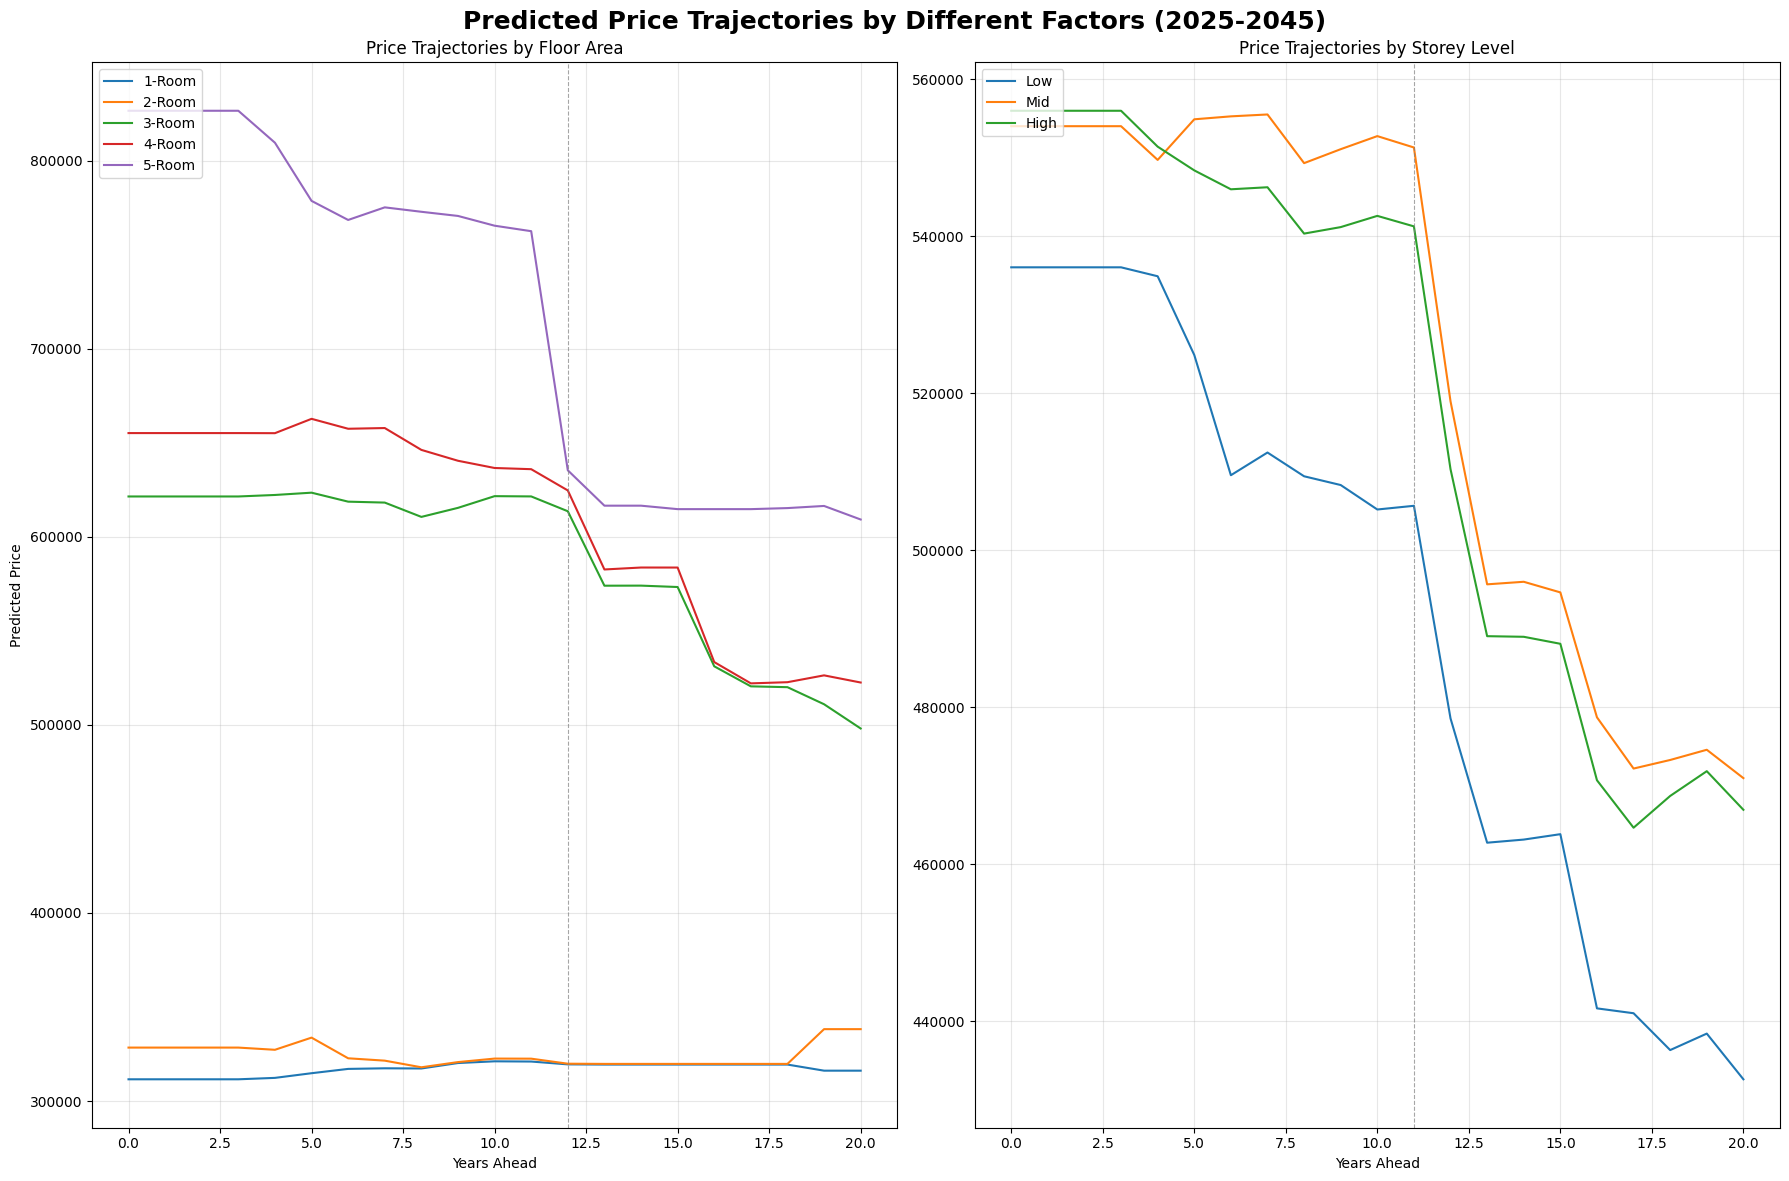

In [115]:
# Subset flats that start with a 99 year lease at year 0
new_flats = predictions_df[predictions_df['Initial_Remaining_Lease'] == 99].copy()
print(f"Number of new flats with 99-year lease at year 0: {len(new_flats)}")

# Visualise price trajectories by factors
fig, ax = plt.subplots(1,2, figsize=(18, 12))

# Plot 1: Price Trajectories by Floor Area
# this shows how price changes as remaining lease decreases, for different flat types
avg_by_area = new_flats.groupby(['Year_Ahead', 'Flat_Type']).agg({
    'Predicted_Price_RF': 'mean'}).reset_index()

for flat_type in floor_area_bins.keys():
    subset = avg_by_area[avg_by_area['Flat_Type'] == flat_type]
    ax[0].plot(subset['Year_Ahead'], subset['Predicted_Price_RF'], label=flat_type)
    
ax[0].set_title('Price Trajectories by Floor Area')
ax[0].set_xlabel('Years Ahead')
ax[0].set_ylabel('Predicted Price')
ax[0].legend(loc = 'upper left')
ax[0].grid(True, alpha=0.3)
ax[0].axvline(x=12, color='gray', linestyle='--', alpha=0.7, linewidth=0.8)

# Plot 2: Price Trajectories by Storey Level
avg_by_storey = new_flats.groupby(['Year_Ahead', 'Storey_Level']).agg({
    'Predicted_Price_RF': 'mean'}).reset_index()

for storey_level in storey_bins.keys():
    subset = avg_by_storey[avg_by_storey['Storey_Level'] == storey_level]
    ax[1].plot(subset['Year_Ahead'], subset['Predicted_Price_RF'], label=storey_level)
ax[1].set_title('Price Trajectories by Storey Level')
ax[1].set_xlabel('Years Ahead')
#ax[1].set_ylabel('Predicted Price')
ax[1].legend(loc = 'upper left')
ax[1].grid(True, alpha=0.3)
ax[1].axvline(x=11, color='gray', linestyle='--', alpha=0.7, linewidth=0.8)


plt.suptitle('Predicted Price Trajectories by Different Factors (2025-2045)', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics of predicted prices for new flats by year ahead and flat type
df = new_flats.groupby(['Year_Ahead', 'Flat_Type']).agg({
    'Predicted_Price_RF': ['mean', 'median', 'std', 'count']
}).round(2).reset_index()   

df

Year_Ahead Flat_Type Predicted_Price_RF                           
                                       mean     median       std count
0            0    1-Room          311548.63  306149.84  12960.59     3
1            0    2-Room          328411.90  339453.83  20112.83     3
2            0    3-Room          621519.89  615437.16  34906.76     3
3            0    4-Room          655234.67  662215.74  12496.78     3
4            0    5-Room          826658.04  846884.72  38447.56     3
..         ...       ...                ...        ...       ...   ...
100         20    1-Room          316135.95  310362.01  13749.15     3
101         20    2-Room          338215.76  330627.42  14170.65     3
102         20    3-Room          498123.51  504783.51  14048.67     3
103         20    4-Room          522572.49  532913.92  28217.05     3
104         20    5-Room          609268.61  630864.73  47415.48     3

[105 rows x 6 columns]